| Roll No.| Subject Code | Assignment No. |
|:-------:|:------------:|:--------------:|
| 2650026 | CS69101      | Lab 3          |

To construct an AVL Tree for a given set of elements stored in a file, implement insertion and deletion operations on the constructed tree, and write the contents of the tree (after these operations) into a new file using in-order traversal.

Prerequisite Code Section
----------------------------

In [1]:
import sys
from io import TextIOWrapper
from typing import Self
import random
import sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pylab import figure

sys.setrecursionlimit(100000) # Fix to avoid RecursionError

prep_arr = [random.randint(1, (i+1)*10) for i in range(5000)] # Random Array of 5000 Elements
# prep_arr.sort() # Sorted Array for Worst Case Scenario
print(prep_arr[:25])
print(len(prep_arr))

# Write the array to a file
f = open("input0.txt", "w")
for i in prep_arr:
    f.write(f"{i}, ")
f.write("\n")
f.close()

del prep_arr
del f

iterations = 0
PRINT_DEBUG = False

[7, 18, 3, 15, 35, 19, 67, 34, 37, 15, 3, 7, 78, 27, 16, 138, 16, 150, 156, 71, 74, 220, 160, 231, 121]
5000


# Q1

Read a set of integer elements from an input file `(input.txt)`.

In [2]:
# Read a set of integer elements from an input file (input.txt)
arr0 = []
data0 = open("input.txt", 'r')

try:
    for line in data0.readlines():
        line_data = line.rstrip().rstrip(',').replace(' ','').split(',') #using rstrip to remove the \n
        for data in line_data:
            arr0.append(int(data))
    data0.close()
except Exception as e:
    sys.exit("[ERROR] Invalid data" + str(e))

In [3]:
print(arr0)

[70, 50, 90, 77, 55]


# Q2 & Q3

Construct a balanced AVL tree by inserting these elements one by one, performing the necessary LL, RR, LR, RL rotations to maintain balance after every insertion.

Implement an insert(key) operation that adds a new node to the AVL tree while preserving
the AVL balance property $$ ( \, \text{balance factor} \in \{ -1, 0, 1 \} \text{ for every node} ) \,. $$

In [4]:
class AVL_Node: # AVL Node class
    def __init__(self):
        self.__lchild = None
        self.__rchild = None
        self.__value = None
        self.__parent = None
        self.__height = None
        self.__balance_factor = None

    def update_height_and_balance(self) -> None:
        # Print statement for debugging
        if PRINT_DEBUG:
            print(f"Updating height and balance factor for node with value: {self.__value}")
            print(f"Left child: {self.__lchild}, Right child: {self.__rchild}")
        self.__height = 1 + max(
            int(-1 if self.__lchild is None else self.__lchild.__get_height()), # type: ignore
            int(-1 if self.__rchild is None else self.__rchild.__get_height()) # type: ignore
        )
        if PRINT_DEBUG:
            print(f"Updated height: {self.__height}")
        self.__balance_factor = (
            (-1 if self.__lchild is None else int(self.__lchild.__get_height())) -
            (-1 if self.__rchild is None else int(self.__rchild.__get_height()))
        ) # type: ignore
        if PRINT_DEBUG:
            print(f"Updated balance factor: {self.__balance_factor}")
        return

    def __get_height(self) -> int:
        # temp_lchild = self.__lchild
        # temp_rchild = self.__rchild
        # temp_lchild_height = -1
        # temp_rchild_height = -1
        # if temp_lchild is not None:
        #     temp_lchild_height = temp_lchild.__get_height()
        # if temp_rchild is not None:
        #     temp_rchild_height = temp_rchild.__get_height()
        # # if self.__height is None:
        # self.__height = 1 + max(temp_lchild_height, temp_rchild_height)
        
        # Update the height if None
        if self.__height is None:
            self.update_height_and_balance()
        # print(f"Node value: {self.__value}, Left child height: {temp_lchild_height}, Right child height: {temp_rchild_height}, Node height: {self.__height}")
        return 0 if self.__height is None else self.__height

    def __set_height(self, height: int) -> None:
        self.__height = height

    height = property(__get_height, __set_height, doc="Height of the node")

    def __get_balance_factor(self) -> int:
        return 0 if self.__balance_factor is None else self.__balance_factor

    def __set_balance_factor(self, balance_factor: int) -> None:
        self.__balance_factor = balance_factor

    balance_factor = property(__get_balance_factor, __set_balance_factor, doc="Balance factor of the node")

    def __get_lchild(self) -> Self | None:
        return self.__lchild

    def __set_lchild(self, lchild: Self | None) -> None: # type: ignore
        if PRINT_DEBUG:
            print(f"Setting left child of node with value {self.__value} to {lchild}")
        self.__lchild = lchild
        if lchild is not None:
            lchild.__parent = self
            lchild.update_height_and_balance()  # Update the height and balance factor of the left child when it is set
        self.update_height_and_balance()  # Update the height and balance factor of the current node when the left child is set

    lchild = property(__get_lchild, __set_lchild, doc="Left child of the node")

    def __get_rchild(self) -> Self | None:
        return self.__rchild

    def __set_rchild(self, rchild: Self | None) -> None: # type: ignore
        if PRINT_DEBUG:
            print(f"Setting right child of node with value {self.__value} to {rchild}")
        self.__rchild = rchild
        if rchild is not None:
            rchild.__parent = self
            rchild.update_height_and_balance()  # Update the height and balance factor of the right child when it is set
        self.update_height_and_balance()  # Update the height and balance factor of the current node when the right child is set

    rchild = property(__get_rchild, __set_rchild, doc="Right child of the node")

    def __get_parent(self) -> Self | None:
        return self.__parent

    def __set_parent(self, parent: Self | None) -> None: # type: ignore
        if PRINT_DEBUG:
            print(f"Setting parent of node with value {self.__value} to {parent}")
        self.__parent = parent
        if parent is not None:
            parent.update_height_and_balance()  # Update the height and balance factor of the parent when it is set

    parent = property(__get_parent, __set_parent, doc="Parent of the node")

    def __get_value(self) -> int | None:
        return self.__value

    def __set_value(self, value: int) -> None:
        self.__value = value

    value = property(__get_value, __set_value, doc="Value of the node")

    def __str__(self) -> str:
        return f"Node(value={self.__value}, height={self.__height}, balance_factor={self.__balance_factor})"

    def __repr__(self) -> str:
        return self.__str__()

def AVL_right_rotate(k2_node: AVL_Node | None, root_node: AVL_Node | None) -> AVL_Node | None:
    if PRINT_DEBUG:
        print(f"Right Rotate: k2_node={k2_node}, root_node={root_node}")
    k1_node = k2_node.lchild if k2_node is not None else None
    if k1_node is None or k2_node is None:
        return root_node

    if PRINT_DEBUG:
        print(f"LL Case: k1_node={k1_node}, k2_node={k2_node}")

    # From Weiss' Data Structures and Algorithm Analysis in C++ (Page 156)
    # Combined CLRS Logic with Weiss' Logic to avoid bugs
    
    # SAFETY CODE
    TEMP_NODE = k1_node.rchild
    OG_PARENT = k2_node.parent
    WAS_RCHILD = bool(OG_PARENT is not None and OG_PARENT.rchild is k2_node)

    # CLRS: x.lchild = y.rchild
    # CLRS: y.rchild = x
    k1_node.rchild = k2_node
    k2_node.lchild = TEMP_NODE

    # Update Parents

    # CLRS: if y.rchild is not None:
    # CLRS:     y.rchild.parent = y
    # CLRS: // However, y.rchild is now x.lchild, so we need to update x.lchild's parent to y
    if PRINT_DEBUG:
        print(f"Updating parent of {k2_node.lchild} to {k2_node}")
    if k2_node.lchild is not None:
        k2_node.lchild.parent = k2_node

    # CLRS: x.parent = y.parent
    k1_node.parent = OG_PARENT

    # CLRS: if y.parent is None:
    # CLRS:     root_node = y
    if OG_PARENT is None:
        # root_node = k1_node
        pass # The input node will always be the root_node for the called function.
    # CLRS: elseif y is y.parent.rchild:
    # CLRS:     y.parent.rchild = x
    elif WAS_RCHILD:
        OG_PARENT.rchild = k1_node
        OG_PARENT.update_height_and_balance() # Update height and balance factor of OG_PARENT
    # CLRS: else:
    # CLRS:     y.parent.lchild = x
    else:
        OG_PARENT.lchild = k1_node
        OG_PARENT.update_height_and_balance() # Update height and balance factor of OG_PARENT

    root_node = k1_node # The input node will always be the root_node for the called function.

    # CLRS: y.parent = x
    # k2_node.parent = k1_node (THIS IS AUTO HANDLED BY SETTER METHOD)

    # if k1_node.rchild is not None:
    #     k1_node.rchild.parent = k1_node

    # root_node = k1_node if OG_PARENT is None else root_node // Copilot told me this

    k1_node.update_height_and_balance() # Update height and balance factor of k1_node
    k2_node.update_height_and_balance() # Update height and balance factor of k2_node

    if k1_node.parent is not None:
        k1_node.parent.update_height_and_balance() # Update height and balance factor of k1_node's parent

    return root_node

def AVL_left_rotate(k1_node: AVL_Node | None, root_node: AVL_Node | None) -> AVL_Node | None:
    if PRINT_DEBUG:
        print(f"Left Rotate: k1_node={k1_node}, root_node={root_node}")
    k2_node = k1_node.rchild if k1_node is not None else None
    if k1_node is None or k2_node is None:
        return root_node

    if PRINT_DEBUG:
        print(f"RR Case: k1_node={k1_node}, k2_node={k2_node}")

    # From Weiss' Data Structures and Algorithm Analysis in C++ (Page 156)
    # Combined CLRS Logic with Weiss' Logic to avoid bugs
    
    # SAFETY CODE
    TEMP_NODE = k2_node.lchild
    OG_PARENT = k1_node.parent
    WAS_RCHILD = bool(OG_PARENT is not None and OG_PARENT.rchild is k1_node)

    # CLRS: x.rchild = y.lchild
    # CLRS: y.lchild = x
    k2_node.lchild = k1_node
    k1_node.rchild = TEMP_NODE

    # Update Parents

    # CLRS: if y.lchild is not None:
    # CLRS:     y.lchild.parent = x
    # CLRS: // However, y.lchild is now x.rchild, so we need to update x.rchild's parent to y
    if k1_node.rchild is not None:
        k1_node.rchild.parent = k1_node

    # CLRS: y.parent = x.parent
    k2_node.parent = OG_PARENT

    # CLRS: if x.parent is None:
    # CLRS:     root_node = y
    if OG_PARENT is None:
        # root_node = k2_node
        pass # The input node will always be the root_node for the called function.
    # CLRS: elseif x is x.parent.lchild:
    # CLRS:     x.parent.lchild = y
    elif WAS_RCHILD:
        OG_PARENT.rchild = k2_node
        OG_PARENT.update_height_and_balance() # Update height and balance factor of OG_PARENT
    # CLRS: else:
    # CLRS:     x.parent.rchild = y
    else:
        OG_PARENT.lchild = k2_node
        OG_PARENT.update_height_and_balance() # Update height and balance factor of OG_PARENT

    root_node = k2_node

    # CLRS: x.parent = y
    # k1_node.parent = k2_node (THIS IS AUTO HANDLED BY SETTER METHOD)
    
    k1_node.update_height_and_balance() # Update height and balance factor of k1_node
    k2_node.update_height_and_balance() # Update height and balance factor of k2_node

    if k2_node.parent is not None:
        k2_node.parent.update_height_and_balance() # Update height and balance factor of k2_node's parent

    return root_node

#   k3
#   /
# k1          =>        k2
#  \                   / \
#   k2                k1 k3
    
def AVL_double_rotate_right(k3_node: AVL_Node | None, root_node: AVL_Node | None) -> AVL_Node | None:
    if PRINT_DEBUG:
        print(f"Double Right Rotate: k3_node={k3_node}, root_node={root_node}")
    k1_node = k3_node.lchild if k3_node is not None else None
    if k1_node is None or k3_node is None:
        return root_node

    if PRINT_DEBUG:
        print(f"Double Right Rotate: k1_node={k1_node}, k3_node={k3_node}")

    root_node = AVL_left_rotate(k1_node, root_node)
    root_node = AVL_right_rotate(k3_node, root_node)

    k3_node.update_height_and_balance() # Update height and balance factor of k3_node
    k1_node.update_height_and_balance() # Update height and balance factor of k1_node

    if k3_node.parent is not None:
        k3_node.parent.update_height_and_balance() # Update height and balance factor of k3_node's parent

    return root_node

# k3
#   \
#   k1          =>      k2
#  /                   / \
# k2                  k1 k3

def AVL_double_rotate_left(k3_node: AVL_Node | None, root_node: AVL_Node | None) -> AVL_Node | None:
    if PRINT_DEBUG:
        print(f"Double Left Rotate: k3_node={k3_node}, root_node={root_node}")
    k1_node = k3_node.rchild if k3_node is not None else None
    if k1_node is None or k3_node is None:
        return root_node

    if PRINT_DEBUG:
        print(f"Double Left Rotate: k1_node={k1_node}, k3_node={k3_node}")

    root_node = AVL_right_rotate(k1_node, root_node)
    root_node = AVL_left_rotate(k3_node, root_node)

    k3_node.update_height_and_balance() # Update height and balance factor of k3_node
    k1_node.update_height_and_balance() # Update height and balance factor of k1_node

    if k3_node.parent is not None:
        k3_node.parent.update_height_and_balance() # Update height and balance factor of k3_node's parent

    return root_node

def AVL_insert(root: AVL_Node | None, value: int) -> AVL_Node | None:
    if (root is None) or (root.value is None):                                      # NULL type handling && Base Case
        new_node = AVL_Node()
        new_node.value = value
        # new_node.update_height_and_balance()
        if PRINT_DEBUG:
            print(f"Created {new_node}")
        return new_node

    if value < root.value:                                                          # X < MID
        root.lchild = AVL_insert(root.lchild, value)
        if PRINT_DEBUG:
            print(f"Inserted {root.lchild} as left child of {root}")
        if root.balance_factor == 2:
            if value < root.lchild.value: # type: ignore
                root = AVL_right_rotate(root, root)                          #LL
                root.update_height_and_balance() if root is not None else None # Update height and balance factor of root after rotation
            else:
                root = AVL_double_rotate_right(root, root)                   #LR
                root.update_height_and_balance() if root is not None else None # Update height and balance factor of root after rotation
    elif value > root.value:                                                        # X > MID
        root.rchild = AVL_insert(root.rchild, value)
        if PRINT_DEBUG:
            print(f"Inserted {root.rchild} as right child of {root}")
        if root.balance_factor == -2:
            if value > root.rchild.value: # type: ignore
                root = AVL_left_rotate(root, root)                           #RR
                root.update_height_and_balance() if root is not None else None # Update height and balance factor of root after rotation
            else:
                root = AVL_double_rotate_left(root, root)                    #RL
                root.update_height_and_balance() if root is not None else None # Update height and balance factor of root after rotation
    else:
        if PRINT_DEBUG:
            print(f"Value {value} already exists in the AVL tree. Duplicate values are not allowed.")
        else:
            pass
    return root

In [5]:
root = AVL_Node()
for i in arr0:
    root = AVL_insert(root, i)

# Q4

Perform the in-order traversal of the final AVL tree and write the traversal output to a new file `(output.txt)`.

In [6]:
def AVL_inorder_traversal(root: AVL_Node | None, out_file: TextIOWrapper | None) -> None:
    if root is None:
        return
    AVL_inorder_traversal(root.lchild, out_file = out_file)
    if out_file is not None:
        print(root.value, end = ', ', file = out_file)
    print(root.value, end = ', ')
    print(root)
    AVL_inorder_traversal(root.rchild, out_file = out_file)

def AVL_preorder_traversal(root: AVL_Node | None, out_file: TextIOWrapper | None) -> None:
    if root is None:
        return
    if out_file is not None:
        print(root.value, end = ', ', file = out_file)
    print(root.value, end = ', ')
    print(root)
    AVL_preorder_traversal(root.lchild, out_file)
    AVL_preorder_traversal(root.rchild, out_file)

def AVL_postorder_traversal(root: AVL_Node | None, out_file: TextIOWrapper | None) -> None:
    if root is None:
        return
    AVL_postorder_traversal(root.lchild, out_file)
    AVL_postorder_traversal(root.rchild, out_file)
    if out_file is not None:
        print(root.value, end = ', ', file = out_file)
    print(root.value, end=', ')
    print(root)

In [7]:
data1 = open("output.txt", 'w')
AVL_inorder_traversal(root, data1)
data1.close()

50, Node(value=50, height=1, balance_factor=-1)
55, Node(value=55, height=0, balance_factor=0)
70, Node(value=70, height=2, balance_factor=0)
77, Node(value=77, height=0, balance_factor=0)
90, Node(value=90, height=1, balance_factor=1)


# Q5

Display the height and balance factor of the tree before and after each operation (optional enhancement).

**Answer:**

```Markdown
Already applied in above code, refer above outputs.
```

# Q6

Plot Height vs number of node

In [8]:
height_store = [] # Store the height of the root node after each insertion
root = AVL_Node() # Reset the root for the new insertions
arr1 = []
with open("input0.txt", 'r') as data0:
    for line in data0.readlines():
        line_data = line.rstrip().rstrip(',').replace(' ','').split(',')
        for data in line_data:
            arr1.append(int(data))

print(arr1)

[7, 18, 3, 15, 35, 19, 67, 34, 37, 15, 3, 7, 78, 27, 16, 138, 16, 150, 156, 71, 74, 220, 160, 231, 121, 154, 32, 185, 203, 60, 74, 217, 29, 217, 44, 109, 85, 39, 24, 147, 25, 29, 29, 174, 442, 83, 319, 21, 5, 109, 368, 290, 488, 22, 435, 410, 560, 130, 374, 331, 509, 256, 499, 109, 307, 281, 200, 377, 518, 232, 569, 238, 497, 498, 544, 476, 381, 511, 390, 270, 785, 520, 216, 630, 799, 853, 90, 336, 221, 468, 111, 258, 612, 342, 851, 792, 52, 914, 12, 760, 282, 12, 1023, 652, 822, 566, 425, 1062, 189, 32, 347, 446, 615, 1073, 625, 826, 1027, 120, 618, 149, 943, 107, 366, 908, 1191, 525, 953, 812, 698, 1169, 1309, 835, 121, 385, 333, 992, 657, 36, 266, 452, 159, 633, 995, 1265, 805, 449, 1337, 664, 1101, 676, 1277, 1192, 105, 594, 937, 1048, 755, 625, 306, 82, 1088, 69, 918, 546, 1099, 1382, 240, 1662, 580, 519, 143, 140, 332, 1340, 1576, 177, 867, 165, 247, 1662, 1441, 143, 1079, 1706, 11, 490, 363, 1177, 880, 1829, 1425, 1799, 619, 746, 1702, 1628, 1139, 1839, 492, 1862, 1582, 86, 558,

In [9]:
for i in arr1:
    root = AVL_insert(root, i)
    print(i)
    print("height: ", root.height if root.height is not None else 0) # type: ignore
    height_store.append(root.height if root.height is not None else 0) # type: ignore

7
height:  0
18
height:  1
3
height:  1
15
height:  2
35
height:  2
19
height:  2
67
height:  2
34
height:  3
37
height:  3
15
height:  3
3
height:  3
7
height:  3
78
height:  3
27
height:  3
16
height:  3
138
height:  4
16
height:  4
150
height:  4
156
height:  4
71
height:  4
74
height:  4
220
height:  4
160
height:  4
231
height:  4
121
height:  4
154
height:  4
32
height:  4
185
height:  5
203
height:  5
60
height:  5
74
height:  5
217
height:  5
29
height:  5
217
height:  5
44
height:  5
109
height:  5
85
height:  5
39
height:  5
24
height:  5
147
height:  5
25
height:  5
29
height:  5
29
height:  5
174
height:  5
442
height:  5
83
height:  5
319
height:  5
21
height:  5
5
height:  5
109
height:  5
368
height:  5
290
height:  6
488
height:  6
22
height:  6
435
height:  6
410
height:  6
560
height:  6
130
height:  6
374
height:  6
331
height:  6
509
height:  6
256
height:  6
499
height:  6
109
height:  6
307
height:  6
281
height:  6
200
height:  6
377
height:  6
518
height:  6
232

In [10]:
AVL_inorder_traversal(root, out_file = None)

3, Node(value=3, height=0, balance_factor=0)
5, Node(value=5, height=1, balance_factor=0)
6, Node(value=6, height=0, balance_factor=0)
7, Node(value=7, height=3, balance_factor=-1)
8, Node(value=8, height=0, balance_factor=0)
9, Node(value=9, height=1, balance_factor=1)
10, Node(value=10, height=2, balance_factor=1)
11, Node(value=11, height=0, balance_factor=0)
12, Node(value=12, height=4, balance_factor=0)
14, Node(value=14, height=0, balance_factor=0)
15, Node(value=15, height=2, balance_factor=-1)
16, Node(value=16, height=1, balance_factor=-1)
17, Node(value=17, height=0, balance_factor=0)
18, Node(value=18, height=3, balance_factor=0)
19, Node(value=19, height=0, balance_factor=0)
21, Node(value=21, height=1, balance_factor=0)
22, Node(value=22, height=0, balance_factor=0)
24, Node(value=24, height=2, balance_factor=1)
25, Node(value=25, height=0, balance_factor=0)
27, Node(value=27, height=5, balance_factor=0)
28, Node(value=28, height=0, balance_factor=0)
29, Node(value=29, hei

In [11]:
height_store_file = open("height_store.txt", 'w')
for height in height_store:
    height_store_file.write(f"{height}, ")
height_store_file.write("\n")
height_store_file.close()

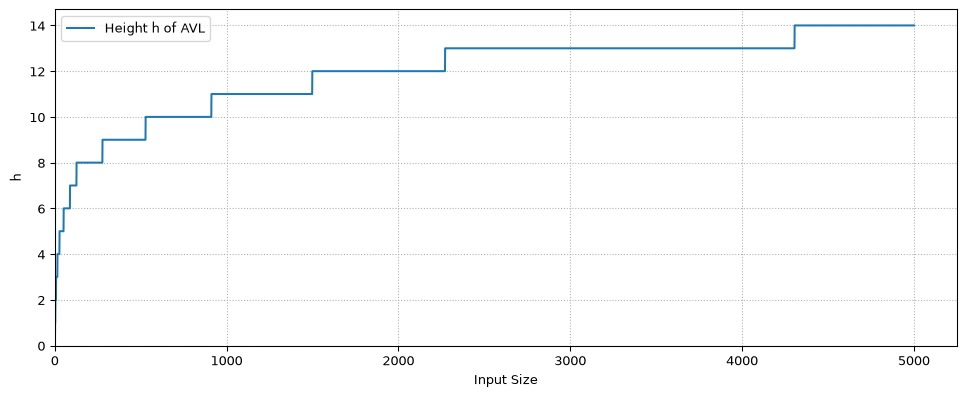

In [12]:
# Plotting the height of the AVL tree after each insertion
figure(figsize=(12, 4.5), dpi=97)

y = height_store[:]
x = [i+1 for i in range(len(y))]

# plt.subplot(3, 1, 2)
plt.plot(x, y, label="Height h of AVL")
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()
plt.xlabel("Input Size")
plt.ylabel("h")
plt.grid(visible=True, linestyle=':')
plt.show()

# Q7

Compare AVL and BST search time

## BST Tree: All Code

In [13]:
iterations = 0 # Global Variable to count iterations during a run

In [14]:
class BST_Node:
    def __init__(self):
        self.lchild = None
        self.rchild = None
        self.value = None
        self.parent = None

def BST_Insert(value, root_node:BST_Node | None = None) -> BST_Node:
    assert value != None, "Value cannot be None"
    y = None
    x = root_node
    global iterations
    while x is not None:
        iterations += 1
        y = x
        if value == x.value: # type: ignore
            if PRINT_DEBUG:
                print(f"Value {value} already exists in the BST. Duplicate values are not allowed.")
            return root_node # type: ignore
        elif value < x.value: # type: ignore
            x = x.lchild # type: ignore
        else:
            x = x.rchild # type: ignore
    new_node = BST_Node()
    new_node.value = value
    new_node.parent = y # type: ignore
    if y is None:
        root_node = new_node
    elif value < y.value: # type: ignore
        y.lchild = new_node # type: ignore
    else:
        y.rchild = new_node # type: ignore
    return root_node # type: ignore

def BST_inorder(root_node:BST_Node | None = None):
    global iterations
    if root_node is None:
        return
    iterations += 1 # type: ignore
    BST_inorder(root_node.lchild)
    print(root_node.value, end=',')
    BST_inorder(root_node.rchild)

def BST_preorder(root_node:BST_Node | None = None):
    global iterations
    if root_node is None:
        return
    iterations += 1 # type: ignore
    print(root_node.value, end=',')
    BST_preorder(root_node.lchild)
    BST_preorder(root_node.rchild)

def BST_postorder(root_node:BST_Node | None = None):
    global iterations
    if root_node is None:
        return
    iterations += 1 # type: ignore
    BST_postorder(root_node.lchild)
    BST_postorder(root_node.rchild)
    print(root_node.value, end=',')

def BST_Search(value, root_node:BST_Node | None = None) -> BST_Node | None:
    global iterations
    if root_node is None:
        return None
    iterations += 1 # type: ignore
    if value == root_node.value:
        return root_node
    elif value < root_node.value:
        return BST_Search(value, root_node.lchild)
    else:
        return BST_Search(value, root_node.rchild)

## AVL Tree Searching Code

In [15]:
def AVL_Search(value, root_node: AVL_Node | None = None) -> AVL_Node | None:
    global iterations
    if root_node is None or root_node.value is None:
        return None
    iterations += 1 # type: ignore
    if value == root_node.value:
        return root_node
    elif value < root_node.value:
        return AVL_Search(value, root_node.lchild)
    else:
        return AVL_Search(value, root_node.rchild)

## Compare iterations for AVL_Search vs BST_Search

In [16]:
# --- AVL: walk down toward the taller child at each step, using cached height ---
def _deepest_avl_value(node: AVL_Node) -> int:
    while node.lchild is not None or node.rchild is not None:
        if node.lchild is None:
            node = node.rchild
        elif node.rchild is None:
            node = node.lchild
        elif node.lchild.height >= node.rchild.height:
            node = node.lchild
        else:
            node = node.rchild
    return node.value  # type: ignore


# --- BST: no cached height, so recurse and track (node, depth) directly ---
def _deepest_bst_value(node: BST_Node, depth: int = 0):
    if node.lchild is None and node.rchild is None:
        return (node.value, depth)
    left = _deepest_bst_value(node.lchild, depth + 1) if node.lchild is not None else (None, -1)
    right = _deepest_bst_value(node.rchild, depth + 1) if node.rchild is not None else (None, -1)
    return left if left[1] >= right[1] else right


def compare_search_iterations(n: int, arr1: list) -> tuple:
    global iterations

    assert isinstance(n, int) and n > 0, "n must be a positive integer"
    assert len(arr1) >= 5000, "arr1 must contain at least 5000 elements"
    assert n <= len(arr1), "n cannot exceed the length of arr1"

    start_idx = random.randint(0, len(arr1) - n)
    elements = arr1[start_idx : start_idx + n]

    bst_root = None
    for val in elements:
        bst_root = BST_Insert(val, bst_root)

    avl_root = None
    for val in elements:
        avl_root = AVL_insert(avl_root, val)

    # Best case: root is always shallowest, regardless of tree shape
    best_bst_value = bst_root.value  # type: ignore
    best_avl_value = avl_root.value  # type: ignore

    # Worst case: deepest node, found via direct descent (no dict of all depths needed)
    worst_bst_value = _deepest_bst_value(bst_root)[0]  # type: ignore
    worst_avl_value = _deepest_avl_value(avl_root)  # type: ignore

    # Random case: any element actually inserted — duplicates are fine,
    # since searching for a repeated value still finds the original node
    random_bst_value = random.choice(elements)
    random_avl_value = random.choice(elements)

    iterations = 0
    BST_Search(best_bst_value, bst_root)
    best_case_bst = iterations

    iterations = 0
    AVL_Search(best_avl_value, avl_root)
    best_case_avl = iterations

    iterations = 0
    BST_Search(worst_bst_value, bst_root)
    worst_case_bst = iterations

    iterations = 0
    AVL_Search(worst_avl_value, avl_root)
    worst_case_avl = iterations

    iterations = 0
    BST_Search(random_bst_value, bst_root)
    random_case_bst = iterations

    iterations = 0
    AVL_Search(random_avl_value, avl_root)
    random_case_avl = iterations

    return (
        best_case_bst, best_case_avl,
        worst_case_bst, worst_case_avl,
        random_case_bst, random_case_avl,
    )

In [17]:
import statistics

results = {}
trials = 10  # adjust as needed

for n in [10, 25, 50, 100, 250, 500, 1000, 2500, 5000]:
    runs = [compare_search_iterations(n, arr1) for _ in range(trials)]

    best_case_bst  = min(run[0] for run in runs)
    best_case_avl  = min(run[1] for run in runs)
    worst_case_bst = max(run[2] for run in runs)
    worst_case_avl = max(run[3] for run in runs)
    random_case_bst = statistics.mean(run[4] for run in runs)
    random_case_avl = statistics.mean(run[5] for run in runs)

    results[n] = (
        best_case_bst, best_case_avl,
        worst_case_bst, worst_case_avl,
        random_case_bst, random_case_avl,
    )
print("Results:\n", results)

Results:
 {10: (1, 1, 8, 4, 3.1, 3), 25: (1, 1, 10, 6, 5.2, 4.1), 50: (1, 1, 14, 7, 6.5, 4.5), 100: (1, 1, 15, 8, 8.6, 5.4), 250: (1, 1, 19, 10, 9.2, 6.4), 500: (1, 1, 25, 11, 11.1, 8), 1000: (1, 1, 42, 12, 10.2, 9.3), 2500: (1, 1, 86, 14, 21.9, 10.5), 5000: (1, 1, 157, 15, 95.9, 10.8)}


In [23]:
columns = [
    "best_case_bst", "best_case_avl",
    "worst_case_bst", "worst_case_avl",
    "random_case_bst", "random_case_avl",
]

search_df = pd.DataFrame.from_dict(results, orient="index", columns=columns)
search_df.index.name = "n"
search_df = search_df.reset_index()

In [24]:
search_df

,n,best_case_bst,best_case_avl,worst_case_bst,worst_case_avl,random_case_bst,random_case_avl
0,10,1,1,8,4,3.1,3.0
1,25,1,1,10,6,5.2,4.1
2,50,1,1,14,7,6.5,4.5
3,100,1,1,15,8,8.6,5.4
4,250,1,1,19,10,9.2,6.4
5,500,1,1,25,11,11.1,8.0
6,1000,1,1,42,12,10.2,9.3
7,2500,1,1,86,14,21.9,10.5
8,5000,1,1,157,15,95.9,10.8


In [25]:
search_df.to_csv("search_iterations_results.csv", index=False)

In [19]:
# Create a function that takes in a size n, then takes first n elements from arr1,
# insert them into a BST and an AVL tree (both separate), and then, return the
# iterations to search for the element that would generate the best case scenario
# in both trees. Similarly, generate the iterations to search for the element 
# that would generate the worst case scenario in both trees.
# Finally, also do the same for a randomised case which would fit between the best
# and worst case scenarios.
# Now, return the iterations in a tuple of the form 
# (best_case_bst, best_case_avl, worst_case_bst, worst_case_avl, random_case_bst, random_case_avl) 